<a href="https://colab.research.google.com/github/jeffersonramelo/M-TODOS-QUANTITATIVOS/blob/main/revis%C3%A3oestat%C3%ADticadescritiva.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis

dados = [
    8,
    9, 9,
    10, 10, 10,
    11, 11, 11, 11,
    12, 12, 12, 12, 12,
    13, 13, 13, 13, 13,
    14, 14, 14, 14,
    15, 15, 15,
    16, 16,
    17
]

# Convert to a pandas Series for easier manipulation
s_dados = pd.Series(dados)

print("Dataset loaded successfully.")

Dataset loaded successfully.


### 1. Tabela de distribuição de frequência, sem organizar em classes

In [ ]:
# Frequência absoluta (fi)
frequencia_absoluta = s_dados.value_counts().sort_index()

# Frequência relativa (fr)
frequencia_relativa = s_dados.value_counts(normalize=True).sort_index()

# Frequência acumulada (Fi)
frequencia_acumulada = frequencia_absoluta.cumsum()

# Frequência relativa acumulada (Fra)
frequencia_relativa_acumulada = frequencia_relativa.cumsum()

# Create the frequency distribution table
df_frequencia = pd.DataFrame({
    'fi': frequencia_absoluta,
    'fr': frequencia_relativa.map('{:.2%}'.format),
    'Fi': frequencia_acumulada,
    'Fra': frequencia_relativa_acumulada.map('{:.2%}'.format)
})

display(df_frequencia)

,fi,fr,Fi,Fra
8,1,3.33%,1,3.33%
9,2,6.67%,3,10.00%
10,3,10.00%,6,20.00%
11,4,13.33%,10,33.33%
12,5,16.67%,15,50.00%
13,5,16.67%,20,66.67%
14,4,13.33%,24,80.00%
15,3,10.00%,27,90.00%
16,2,6.67%,29,96.67%
17,1,3.33%,30,100.00%


### 2. Média aritmética

In [ ]:
media_aritmetica = s_dados.mean()
print(f"Média Aritmética: {media_aritmetica:.2f}")

Média Aritmética: 12.50


### 3. Mediana

In [ ]:
mediana = s_dados.median()
print(f"Mediana: {mediana:.2f}")

Mediana: 12.50


### 4. Moda

In [ ]:
moda = s_dados.mode()
print(f"Moda: {', '.join(map(str, moda.tolist()))}")

Moda: 12, 13


### 5. Amplitude Total

In [ ]:
amplitude_total = s_dados.max() - s_dados.min()
print(f"Amplitude Total: {amplitude_total}")

Amplitude Total: 9


### 6. Variância

In [ ]:
# Default `ddof=1` for sample variance
variancia = s_dados.var()
print(f"Variância: {variancia:.2f}")

Variância: 5.09


### 7. Desvio Padrão

In [ ]:
# Default `ddof=1` for sample standard deviation
desvio_padrao = s_dados.std()
print(f"Desvio Padrão: {desvio_padrao:.2f}")

Desvio Padrão: 2.26


### 8. Coeficiente de Variação

In [ ]:
coeficiente_variacao = (desvio_padrao / media_aritmetica) * 100
print(f"Coeficiente de Variação: {coeficiente_variacao:.2f}%")

Coeficiente de Variação: 18.04%


### 9. Percentil 60

In [ ]:
percentil_60 = s_dados.quantile(0.60)
print(f"Percentil 60: {percentil_60:.2f}")

Percentil 60: 13.00


### 10. Quartil 2

In [ ]:
quartil_2 = s_dados.quantile(0.50) # Equivalent to the median
print(f"Quartil 2: {quartil_2:.2f}")

Quartil 2: 12.50


### 11. Quintil 3

In [ ]:
quintil_3 = s_dados.quantile(0.60) # 3rd quintile is 60th percentile
print(f"Quintil 3: {quintil_3:.2f}")

Quintil 3: 13.00


### 12. Decil 4

In [ ]:
decil_4 = s_dados.quantile(0.40)
print(f"Decil 4: {decil_4:.2f}")

Decil 4: 12.00


### 13. Assimetria

In [ ]:
assimetria = skew(s_dados)
print(f"Assimetria: {assimetria:.2f}")

Assimetria: 0.00


### 14. Curtose

In [ ]:
curtose = kurtosis(s_dados)
print(f"Curtose: {curtose:.2f}")

Curtose: -0.66


### 15. Boxplot

/tmp/ipykernel_1541/564785433.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=s_dados, palette='viridis')


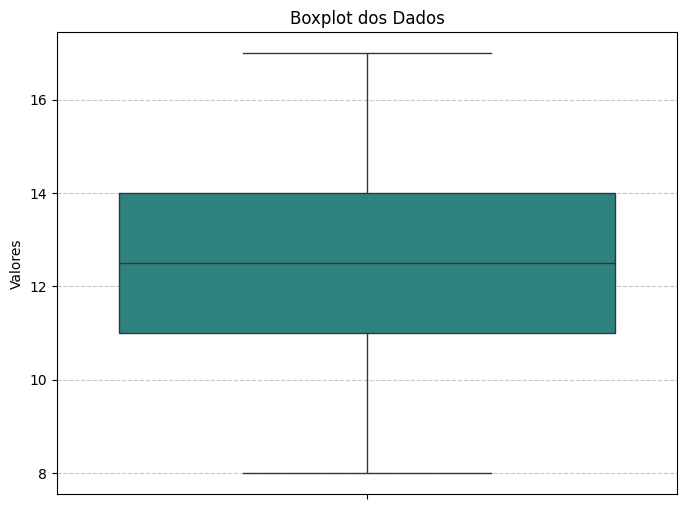

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(y=s_dados, palette='viridis')
plt.title('Boxplot dos Dados')
plt.ylabel('Valores')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### 16. Histograma

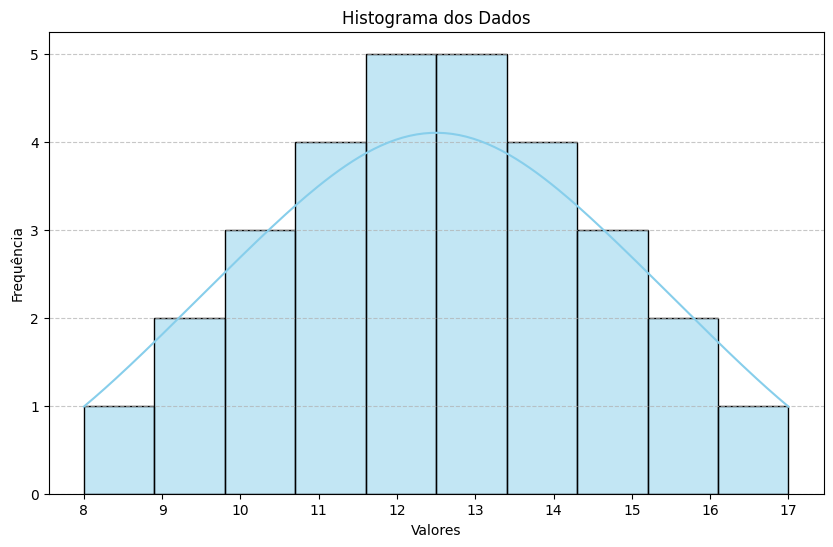

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(s_dados, bins=len(s_dados.unique()), kde=True, color='skyblue', edgecolor='black')
plt.title('Histograma dos Dados')
plt.xlabel('Valores')
plt.ylabel('Frequência')
plt.xticks(s_dados.unique())
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### 17. Gráfico de Ogiva de Galton (Polígono de Frequência Acumulada)

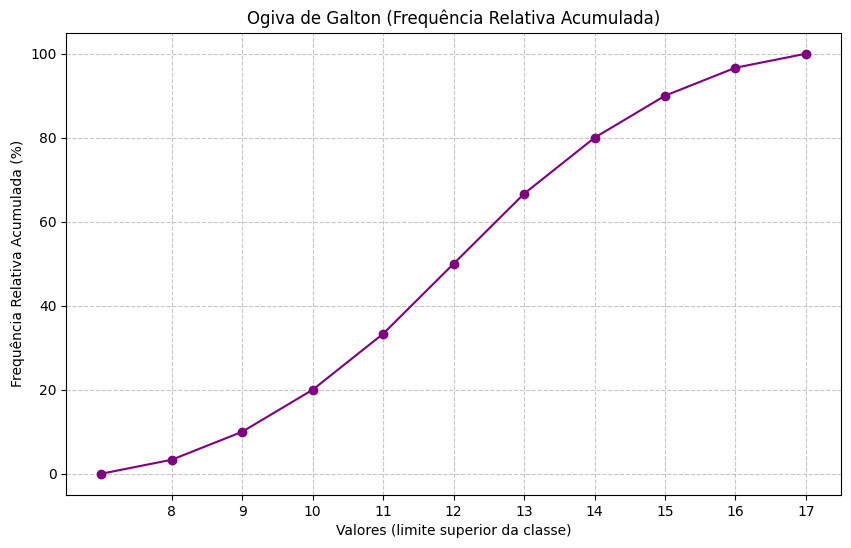

In [ ]:
plt.figure(figsize=(10, 6))

# For ogive, we use the upper bounds of the values and their cumulative frequencies
# The distinct values serve as the 'classes' here since no explicit classes were defined
values = df_frequencia.index.tolist()
cum_freq_relative = (frequencia_relativa_acumulada * 100).tolist() # Use relative cumulative frequency in percentage

# To start the ogive at 0, we add a point before the first value
plt.plot([min(values) - 1] + values, [0] + cum_freq_relative, marker='o', linestyle='-', color='purple')

plt.title('Ogiva de Galton (Frequência Relativa Acumulada)')
plt.xlabel('Valores (limite superior da classe)')
plt.ylabel('Frequência Relativa Acumulada (%)') # Updated y-axis label
plt.xticks(values) # Set x-ticks to the distinct values
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()